In [2]:
import pandas as pd
import polars as pl
import numpy as np
import os
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
import pickle

from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import VotingRegressor

import warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None

/home/jx1421/JS-Kaggle-JX/js-venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configurations

In [3]:
class CONFIG:
    seed = 42
    target_col = "responder_6"
    feature_cols = ["symbol_id", "time_id"] \
        + [f"feature_{idx:02d}" for idx in range(79)] \
        + [f"responder_{idx}_lag_1" for idx in range(9)]
    categorical_cols = []

# Load Data

In [4]:
train = pl.scan_parquet("train.parquet").collect().to_pandas()
valid = pl.scan_parquet("valid.parquet").collect().to_pandas()
train.shape, valid.shape

((21022056, 104), (1082224, 104))

In [5]:
X_train = train[ CONFIG.feature_cols ]
y_train = train[ CONFIG.target_col ]
w_train = train[ "weight" ]
X_valid = valid[ CONFIG.feature_cols ]
y_valid = valid[ CONFIG.target_col ]
w_valid = valid[ "weight" ]

X_train.shape, y_train.shape, w_train.shape, X_valid.shape, y_valid.shape, w_valid.shape

((21022056, 90),
 (21022056,),
 (21022056,),
 (1082224, 90),
 (1082224,),
 (1082224,))

# Train naive XGb

In [6]:
def get_model(seed):
    # XGBoost parameters
    XGB_Params = {
        'learning_rate': 0.05,
        'max_depth': 6,
        'n_estimators': 200,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 1,
        'reg_lambda': 5,
        'random_state': seed,
        'tree_method': 'gpu_hist',
        'device' : 'cuda',
        'n_gpus' : 2
    }
    
    XGB_Model = XGBRegressor(**XGB_Params)
    return XGB_Model

In [7]:
model = get_model(CONFIG.seed)
model.fit( X_train, y_train, sample_weight=w_train)
y_pred_train = model.predict(X_train)
y_pred_valid = model.predict(X_valid)
train_score = r2_score(y_train, y_pred_train, sample_weight=w_train )
valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
train_score, valid_score

(0.034636578581196065, 0.005550710799321679)

# Now change symbol_id to dummy categorical and refit naive XGb

In [8]:
train["symbol_id"] = train["symbol_id"].astype('category')
valid["symbol_id"] = valid["symbol_id"].astype('category')
X_train = train[ CONFIG.feature_cols ]
y_train = train[ CONFIG.target_col ]
w_train = train[ "weight" ]
X_valid = valid[ CONFIG.feature_cols ]
y_valid = valid[ CONFIG.target_col ]
w_valid = valid[ "weight" ]

X_train.shape, y_train.shape, w_train.shape, X_valid.shape, y_valid.shape, w_valid.shape

((21022056, 90),
 (21022056,),
 (21022056,),
 (1082224, 90),
 (1082224,),
 (1082224,))

# Enable XGb to deal with categorical

In [9]:
def get_model(seed):
    # XGBoost parameters
    XGB_Params = {
        'learning_rate': 0.05,
        'max_depth': 6,
        'n_estimators': 200,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 1,
        'reg_lambda': 5,
        'random_state': seed,
        'tree_method': 'gpu_hist',
        'device' : 'cuda',
        'n_gpus' : 2,
        'enable_categorical': True,
        'use_label_encoder': False
    }
    
    XGB_Model = XGBRegressor(**XGB_Params)
    return XGB_Model

In [10]:
%%time
model = get_model(CONFIG.seed)
model.fit( X_train, y_train, sample_weight=w_train)
y_pred_train = model.predict(X_train)
y_pred_valid = model.predict(X_valid)
train_score = r2_score(y_train, y_pred_train, sample_weight=w_train )
valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
train_score, valid_score

CPU times: user 12min 3s, sys: 12.1 s, total: 12min 15s
Wall time: 1min 31s


(0.036868743428252526, 0.006652281256338433)

# Combine train and valid, and re-train XGB on whole dataset

In [16]:
# # Trick of boosting LB score: 0.45->0.49
train = pd.concat([train, valid]).reset_index(drop=True)
train.shape

(22104280, 104)

In [17]:
X_train = train[ CONFIG.feature_cols ]
y_train = train[ CONFIG.target_col ]
w_train = train[ "weight" ]
print(X_train.dtypes)


symbol_id            category
time_id                 int16
feature_00            float32
feature_01            float32
feature_02            float32
                       ...   
responder_4_lag_1     float32
responder_5_lag_1     float32
responder_6_lag_1     float32
responder_7_lag_1     float32
responder_8_lag_1     float32
Length: 90, dtype: object


In [18]:
%%time
model = get_model(CONFIG.seed)
model.fit( X_train, y_train, sample_weight=w_train)
y_pred_train = model.predict(X_train)
y_pred_valid = model.predict(X_valid)
train_score = r2_score(y_train, y_pred_train, sample_weight=w_train )
valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
train_score, valid_score

CPU times: user 12min 30s, sys: 10.6 s, total: 12min 40s
Wall time: 1min 35s


(0.03503797343254367, 0.016447055822342405)

In [19]:
cv_detail = { symbol_id : 0 for symbol_id in range(39) }
for symbol_id, gdf in valid.groupby("symbol_id"):
    X_valid = gdf[ CONFIG.feature_cols ]
    y_valid = gdf[ CONFIG.target_col ]
    w_valid = gdf[ "weight" ]
    y_pred_valid = model.predict(X_valid)
    score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
    cv_detail[symbol_id] = score
    
    print(f"symbol_id = {symbol_id}, score = {score:.5f}")

symbol_id = 0, score = 0.00058
symbol_id = 1, score = 0.00859
symbol_id = 2, score = 0.00555
symbol_id = 3, score = 0.01021
symbol_id = 4, score = 0.03037
symbol_id = 5, score = 0.00721
symbol_id = 6, score = 0.00642
symbol_id = 7, score = 0.00538
symbol_id = 8, score = 0.01970
symbol_id = 9, score = 0.01514
symbol_id = 10, score = 0.00721
symbol_id = 11, score = 0.01367
symbol_id = 12, score = 0.00972
symbol_id = 13, score = 0.05192
symbol_id = 14, score = 0.00613
symbol_id = 15, score = 0.00130
symbol_id = 16, score = 0.01389
symbol_id = 17, score = 0.02164
symbol_id = 18, score = 0.00810
symbol_id = 19, score = 0.02505
symbol_id = 20, score = 0.01950
symbol_id = 21, score = 0.00913
symbol_id = 22, score = 0.02742
symbol_id = 23, score = 0.00414
symbol_id = 24, score = 0.00313
symbol_id = 25, score = 0.02022
symbol_id = 26, score = 0.00079
symbol_id = 27, score = 0.00466
symbol_id = 28, score = 0.00887
symbol_id = 29, score = 0.00742
symbol_id = 30, score = -0.00088
symbol_id = 31, s

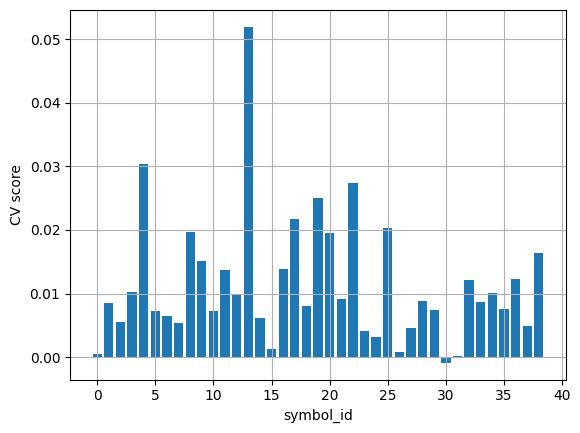

In [20]:
sids = list(cv_detail.keys())
plt.bar(sids, [cv_detail[sid] for sid in sids])
plt.grid()
plt.xlabel("symbol_id")
plt.ylabel("CV score")
plt.show()

# Save the XGB model

In [21]:
result = {
    "model" : model
}
with open("XGB.pkl", "wb") as fp:
    pickle.dump(result, fp)